# **Predicting Impact of Air Pollution on Respiratory Health in Taiwan using LSTM**


---



## **0. Environment Setup**

### **0.1 Imports**

In [ ]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### **0.2 Load the Dataset**

In [ ]:
!pip install -q gdown

In [ ]:
import gdown
import pandas as pd

# Replace this with your actual file ID from the Google Drive link
file_id = "1EvEPTsQb6jWyz6cSgfTouAzU0EkUBkoL"
output = "merged_air_pollution_hospital_data.csv"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

# Now read it
df = pd.read_csv(output)

Downloading...
From: https://drive.google.com/uc?id=1EvEPTsQb6jWyz6cSgfTouAzU0EkUBkoL
To: /content/merged_air_pollution_hospital_data.csv
100%|██████████| 41.6M/41.6M [00:00<00:00, 77.8MB/s]


In [ ]:
df

,county,year,week,aqi,so2,co,o3,o3_8hr,pm10,pm2.5,...,no,co_8hr,pm2.5_avg,pm10_avg,so2_avg,visit_type,age_group,visits_for_acute_ari,total_nhi_visits,county_code
0,Changhua County,2016,47,45.796610,2.981034,0.386307,25.232184,32.288889,38.156069,15.191083,...,1.840588,0.432815,13.491525,38.875706,NaN,inpatient,0~2,5,144,10007
1,Changhua County,2016,47,45.796610,2.981034,0.386307,25.232184,32.288889,38.156069,15.191083,...,1.840588,0.432815,13.491525,38.875706,NaN,inpatient,13~15,0,27,10007
2,Changhua County,2016,47,45.796610,2.981034,0.386307,25.232184,32.288889,38.156069,15.191083,...,1.840588,0.432815,13.491525,38.875706,NaN,inpatient,16~18,0,14,10007
3,Changhua County,2016,47,45.796610,2.981034,0.386307,25.232184,32.288889,38.156069,15.191083,...,1.840588,0.432815,13.491525,38.875706,NaN,inpatient,19~24,0,78,10007
4,Changhua County,2016,47,45.796610,2.981034,0.386307,25.232184,32.288889,38.156069,15.191083,...,1.840588,0.432815,13.491525,38.875706,NaN,inpatient,25~64,1,1160,10007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136575,Yunlin County,2024,35,47.178819,1.175044,0.167203,37.047544,37.082986,23.723776,14.022727,...,1.047890,0.114062,13.901389,23.076389,0.690972,outpatient,19~24,542,4327,10009
136576,Yunlin County,2024,35,47.178819,1.175044,0.167203,37.047544,37.082986,23.723776,14.022727,...,1.047890,0.114062,13.901389,23.076389,0.690972,outpatient,25~64,5123,60055,10009
136577,Yunlin County,2024,35,47.178819,1.175044,0.167203,37.047544,37.082986,23.723776,14.022727,...,1.047890,0.114062,13.901389,23.076389,0.690972,outpatient,3~6,2037,7430,10009
136578,Yunlin County,2024,35,47.178819,1.175044,0.167203,37.047544,37.082986,23.723776,14.022727,...,1.047890,0.114062,13.901389,23.076389,0.690972,outpatient,65+,2127,43777,10009


## **What do we want to consider?**



1.   **Air Pollution Impact by Age Group - Whole Taiwan:**

- Prediction of number of hospital visits for next week for one specific age group

2.   **Air Pollution Impact by Age Group - County Dependent:**

- Prediction of number of hospital visits for next week for one specific age group for every county

3.   **Overall - Age Group Independent**

- Consider only the overall number of hospital visits for all Taiwan (i.e. sum up all visits for one day in all counties)
- average pollution data representing whole Taiwan (pm2.4, pm10, no2) have to be calculated

4. **County-Dependent - Age Group Independent:**

- Consider for every county the pollution data and the number of hospital visits
- most reasonable since average pollution for whole country might not be that representative
- located in cleaned_dataset







---



## **1. National-Level Hospital Visits**
- summarize all number from all counties for a unified national-wide values
- across all age groups

### **1.1 Data Preprocessing**



####**1.1.1 Select Features and Target**

Air Pollution Features:
- Air Qualtiy Index (aqi)
- Sulfur dioxide (so2)
- Carbon monoxide (co)
- Carbon monoxide for 8hours (co_8hr)
- Ozone (o3)
- Ozone for 8hours (o3_8hr)
- Particulate matter < 10μm (pm10)
- Particulate matter < 2.5μm (pm2.5)
- Nitrogen dioxide (no2)

Target Variable:
- Number of acute respiratory infections (visits_for_acute_uri)


In [ ]:
features = [
    'aqi', 'so2', 'co', 'o3', 'o3_8hr',
    'pm10', 'pm2.5', 'no2', 'nox', 'no',
    'co_8hr', 'pm2.5_avg', 'pm10_avg'
]

target = 'visits_for_acute_ari'

In [ ]:
# Group by year and week and compute mean over all counties
df_national = df.groupby(['year', 'week']).agg({**{feat: 'mean' for feat in features},
                                                target: 'sum'}).reset_index()

# Sort by time
df_national = df_national.sort_values(by=['year', 'week'])

# @title Display
df_national

,year,week,aqi,so2,co,o3,o3_8hr,pm10,pm2.5,no2,nox,no,co_8hr,pm2.5_avg,pm10_avg,visits_for_acute_ari
0,2016,47,42.568552,2.105606,0.388468,25.835948,30.624666,30.582494,13.225689,12.628235,15.562949,2.936098,0.430843,12.306529,31.597068,511068
1,2016,48,60.328309,2.709024,0.377093,29.922075,29.581809,48.463414,20.671629,12.918046,16.080272,3.158431,0.380132,19.580425,46.863212,533637
2,2016,49,77.619739,2.961610,0.387871,33.637008,33.698048,57.683873,26.565574,13.702574,16.813242,3.116425,0.387914,26.464602,57.713000,533438
3,2016,50,74.960729,2.852205,0.422256,30.346832,30.338754,53.945994,25.519723,14.889179,18.736057,3.851050,0.420331,25.292127,53.911579,553438
4,2016,51,84.774273,3.136146,0.486974,29.296188,29.330049,60.161573,29.956248,15.880678,20.391486,4.513233,0.490264,29.616181,60.090475,552199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,2024,31,29.398265,0.938529,0.176346,21.736508,21.558950,18.728337,8.165564,5.262408,7.214316,1.910131,0.129795,8.064341,18.216297,335577
402,2024,32,40.179119,1.060955,0.214799,28.527715,28.551187,21.417051,11.767835,6.275841,7.979994,1.662343,0.164634,11.746360,20.948994,341429
403,2024,33,28.955989,0.986157,0.209578,22.980744,23.124506,16.671394,7.366745,6.199437,8.294493,2.053224,0.160837,7.412519,16.348464,371439
404,2024,34,27.651581,1.024379,0.175991,20.313276,20.147738,17.146172,7.670394,5.668339,7.818842,2.110017,0.129147,7.468983,16.491173,386379


####**1.1.2 Scale Features for LSTM**

- Scales the input features using z-score normalization to ensure uniform contribution to the model
- Standardizes the target variable (number of ARI visits) to stabilize training and improve convergence
- Applies global normalization across all data (not per county)
- Normalized data is particularly important for LSTM models, which are sensitive to the scale of input features due to their recurrent structure

#### Why?
- Prevent exploding/vanishing gradients
- Ensure all features contribute equally
- Speed up training
- No bias of feature

In [ ]:
# Scale features
feature_scaler = StandardScaler()
df_national[features] = feature_scaler.fit_transform(df_national[features])

# Scale target
target_scaler = StandardScaler()
df_national[[target]] = target_scaler.fit_transform(df_national[[target]])

### **1.2 LSTM Model Definition**

In [ ]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(SimpleLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.LSTM = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.LSTM(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

### **1.3 Helper Function to create sequences for LSTM**

- Creates input sequences from time series data using a sliding window
- Used to generate sequences of varying lengths for LSTM training

In [ ]:
def create_sequences(df, features, target, window_size=7, group_by_col=None):
    sequences, targets = [], []
    grouped = df.groupby(group_by_col) if group_by_col else [(None, df)]
    for _, group in grouped:
        group = group.sort_values(['year', 'week'])
        X = group[features].values
        y = group[target].values
        for i in range(len(group) - window_size):
            seq_x = X[i:i + window_size]
            seq_y = y[i + window_size]
            sequences.append(seq_x)
            targets.append(seq_y)
    return np.array(sequences), np.array(targets)

### **1.4 Training LSTM for different sequence lengths**

- Tests multiple sequence lengths to evaluate how much past information improves prediction performance
- Generates input sequences using a fixed window (max length), then trims them for each tested length
- Trains and evaluates a new LSTM model for each sequence length using standardized national data
- Stores the predicted and true values (rescaled) for later comparison


In [ ]:
# @title Training LSTM {"vertical-output":true,"display-mode":"both"}
sequence_lengths = [1, 2, 3, 4, 5, 6, 7, 10, 15, 25, 50]

# Create the maximum sequences first
max_seq_len = max(sequence_lengths)
X_all, y_all = create_sequences(df_national, features, target, window_size=max_seq_len)

# Split
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y_all, test_size=0.2, shuffle=True)

results = []

for seq_len in sequence_lengths:
    print(f"\n=== Training with Sequence Length: {seq_len} ===")

    # Reduce sequences to current length
    X_train = X_train_all[:, -seq_len:, :]
    X_test = X_test_all[:, -seq_len:, :]

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_all, dtype=torch.float32).unsqueeze(-1)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_all, dtype=torch.float32).unsqueeze(-1)

    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=16)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=16)

    model = SimpleLSTM(input_size=len(features), hidden_size=64, output_size=1, num_layers=1)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 150

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {total_loss / len(train_loader):.4f}")

    # Evaluate
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor).squeeze().numpy()
        y_true = y_test_tensor.squeeze().numpy()

    # Inverse transform
    y_pred_rescaled = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_true_rescaled = target_scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()

    timeline = df_national[['year', 'week']].iloc[-len(y_test_all):].astype(str)
    labels = timeline['year'] + '-W' + timeline['week']

    results.append((seq_len, labels, y_true_rescaled, y_pred_rescaled))


406 rows in group

=== Training with Sequence Length: 1 ===
Epoch 0, Loss: 1.0306
Epoch 10, Loss: 0.7394
Epoch 20, Loss: 0.6741
Epoch 30, Loss: 0.6208
Epoch 40, Loss: 0.5895
Epoch 50, Loss: 0.5655
Epoch 60, Loss: 0.5442
Epoch 70, Loss: 0.5256
Epoch 80, Loss: 0.5094
Epoch 90, Loss: 0.4944
Epoch 100, Loss: 0.4800
Epoch 110, Loss: 0.4659
Epoch 120, Loss: 0.4523
Epoch 130, Loss: 0.4395
Epoch 140, Loss: 0.4276

=== Training with Sequence Length: 2 ===
Epoch 0, Loss: 0.9341
Epoch 10, Loss: 0.6555
Epoch 20, Loss: 0.5454
Epoch 30, Loss: 0.4749
Epoch 40, Loss: 0.4119
Epoch 50, Loss: 0.3654
Epoch 60, Loss: 0.3256
Epoch 70, Loss: 0.2876
Epoch 80, Loss: 0.2499
Epoch 90, Loss: 0.2130
Epoch 100, Loss: 0.1783
Epoch 110, Loss: 0.1474
Epoch 120, Loss: 0.1229
Epoch 130, Loss: 0.1050
Epoch 140, Loss: 0.0899

=== Training with Sequence Length: 3 ===
Epoch 0, Loss: 0.9544
Epoch 10, Loss: 0.5836
Epoch 20, Loss: 0.4254
Epoch 30, Loss: 0.3249
Epoch 40, Loss: 0.2625
Epoch 50, Loss: 0.2109
Epoch 60, Loss: 0.167

### **1.5 Plotting the Results**

- Plots the true and predicted ARI visit counts for each tested sequence length
- Helps visualize the impact of sequence length on prediction accuracy
- Each subplot corresponds to a different model trained with a specific sequence length
- Provides a qualitative comparison of how much past temporal context improves national-level forecasts

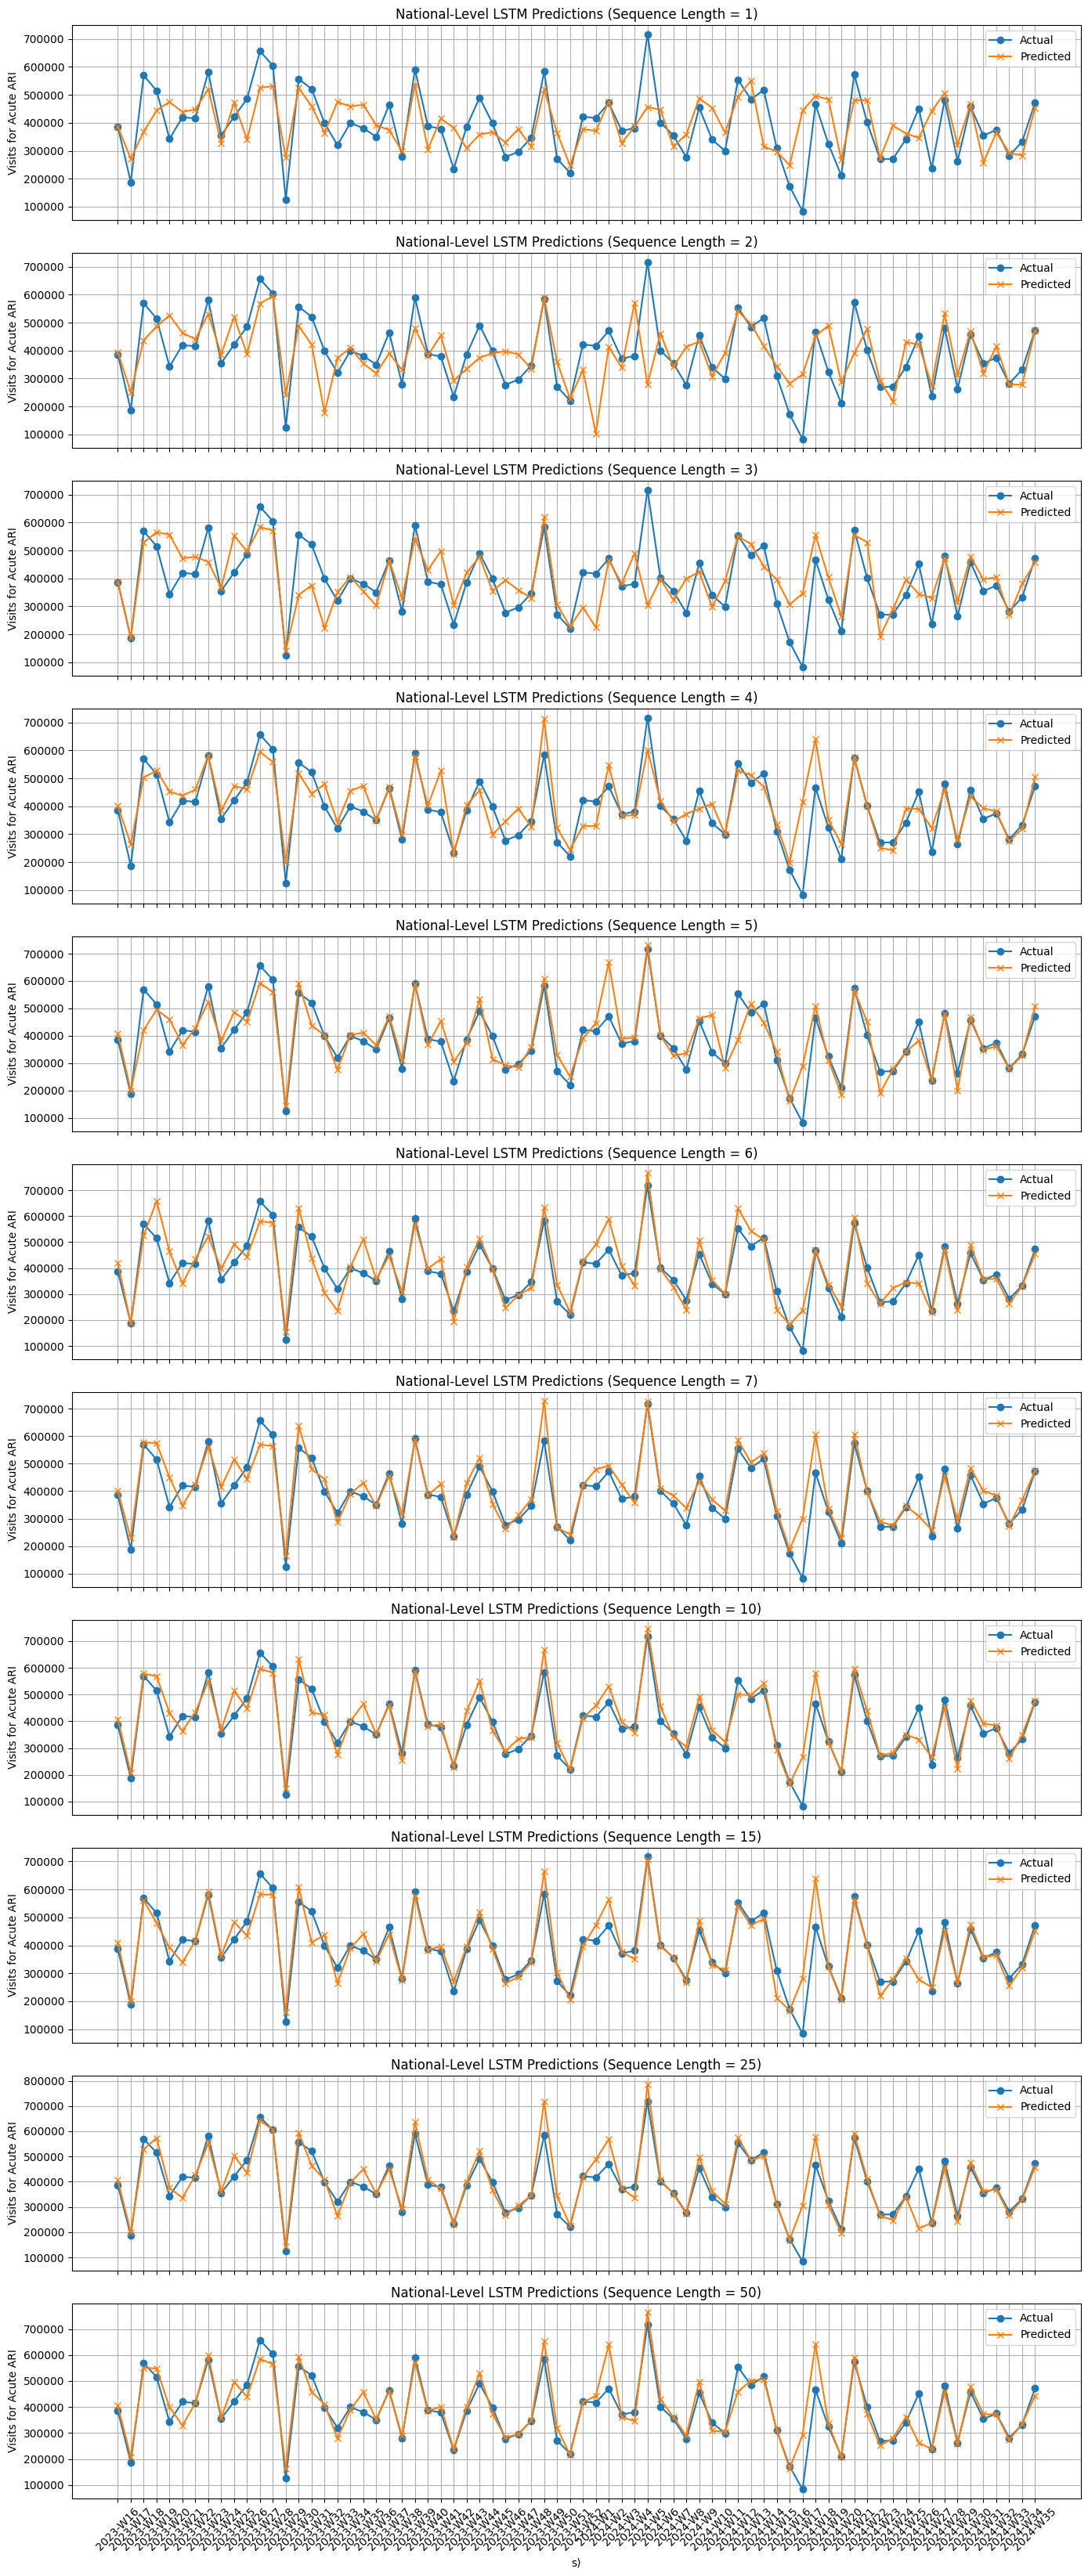

In [ ]:
# @title Result {"vertical-output":true,"display-mode":"both"}
fig, axs = plt.subplots(len(results), 1, figsize=(14, 3 * len(results)), sharex=True)

for i, (seq_len, labels, y_true, y_pred) in enumerate(results):
    axs[i].plot(labels, y_true, label='Actual', marker='o')
    axs[i].plot(labels, y_pred, label='Predicted', marker='x')
    axs[i].set_title(f'National-Level LSTM Predictions (Sequence Length = {seq_len})')
    axs[i].set_ylabel('Visits for Acute ARI')
    axs[i].grid(True)
    axs[i].legend()

axs[-1].set_xlabel('s)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **1.5.2 Plot percentage of predictions that fall within a ±delta of the actual value**

- Defines fixed absolute error thresholds to evaluate prediction accuracy
- For each sequence length, calculates the percentage of predictions falling within ±10k, ±20k, ±30k, and ±40k of the true value
- Aggregates these accuracy scores and visualizes them as grouped bar plots
- Allows for direct comparison of sequence length performance based on tolerance to absolute error

In [ ]:
# Define the belly thresholds
belly_thresholds = [10000, 20000, 30000, 40000]
belly_stats = {threshold: [] for threshold in belly_thresholds}

# Compute belly accuracy per sequence length
for seq_len, _, y_true, y_pred in results:
    for threshold in belly_thresholds:
        within_belly = np.abs(y_true - y_pred) <= threshold
        percentage = np.mean(within_belly) * 100
        belly_stats[threshold].append(percentage)

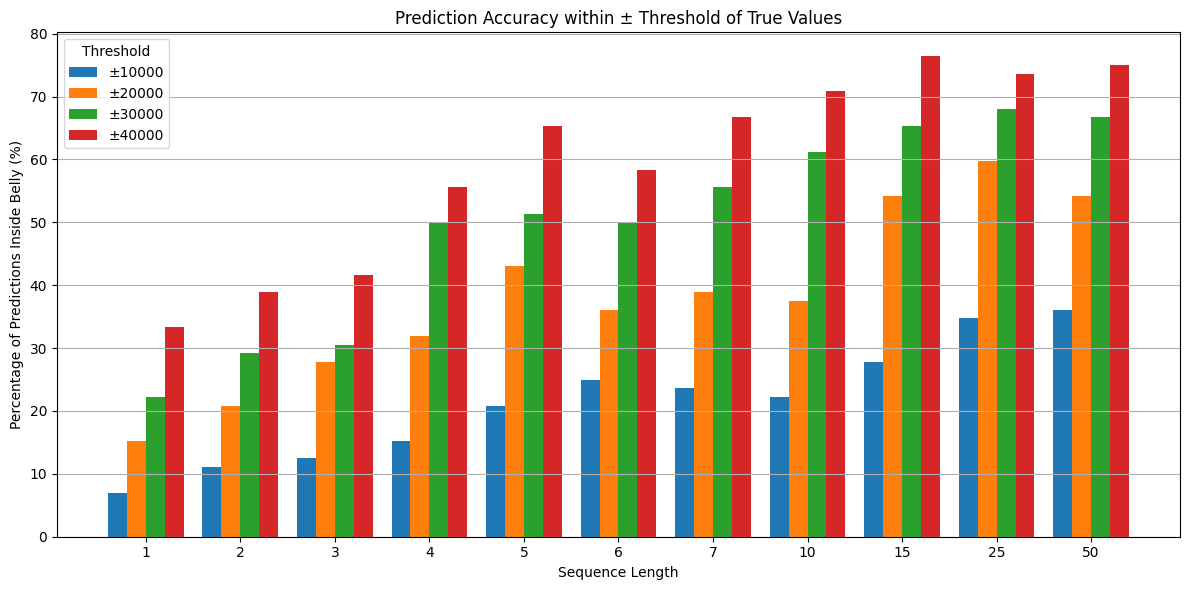

In [ ]:
# @title Belly Accuracy {"vertical-output":true,"display-mode":"form"}
# Plot belly accuracies
x = np.arange(len(sequence_lengths))  # Label positions
width = 0.2  # Width of each bar group

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars for each threshold
for i, threshold in enumerate(belly_thresholds):
    ax.bar(x + i * width, belly_stats[threshold], width, label=f'±{threshold}')

ax.set_xlabel('Sequence Length')
ax.set_ylabel('Percentage of Predictions Inside Belly (%)')
ax.set_title('Prediction Accuracy within ± Threshold of True Values')
ax.set_xticks(x + width * (len(belly_thresholds) - 1) / 2)
ax.set_xticklabels(sequence_lengths)
ax.legend(title='Threshold')
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

### **1.6 Result analysis: sequence length vs accuracy**


- Longer sequences (≥ 7 weeks) significantly improve prediction accuracy
- The model performs poorly for short sequences (1–3 weeks), due to insufficient temporal context
- Gains in accuracy become smaller beyond 10 weeks
- ±40k threshold leads to the highest accuracy (over 80% for 15-week sequences), indicating that the model captures general trends better than precise values.



### **1.7 Limitations and improvements of the nation-wide LSTM approach**

**Limitations:**
- Averaging all counties removes local patterns and flattens important variations
- Differences in county size and population are ignored
- The link between air quality and ARI visits is weakened, since pollution values no longer match the population actually exposed
- Model might underperform due to lack of diversity in the input data and size of dataset

**Improvements:**
- Add Pearson correlation or other metrics to evaluate temporal alignment
- Compare with models using raw county-level sequences instead of national aggregates




---



## **2. County-level hospital visits**
- summarize the number of patient of each counties
- across all age groups

### **2.1 Data preprocessing**

This section prepares the county-level dataset by aggregating pollution and health data weekly for each county. It groups the data by year, week, and county code.

- Selects pollution features and the ARI visits target
- Computes the mean for pollution features
- Computes the sum for ARI visit counts
- Sorts the dataset chronologically within each county
- Encodes county_code into a numerical ID (county_encoded) for embedding use in the model

In [ ]:
# @title Data Preprocessing {"vertical-output":true,"display-mode":"form"}
from sklearn.preprocessing import LabelEncoder


features_county_2 = [
    'aqi', 'so2', 'co', 'o3', 'o3_8hr',
    'pm10', 'pm2.5', 'no2', 'nox', 'no',
    'co_8hr', 'pm2.5_avg', 'pm10_avg'
]

target_county_2 = 'visits_for_acute_ari'

# Group by year, week, and county_code
df_county = df.groupby(['year', 'week', 'county_code']).agg({
    **{feat: 'mean' for feat in features_county_2},
    target_county_2: 'sum'
}).reset_index()
df_county = df_county.dropna(subset=features_county_2).reset_index(drop=True)

# Sort by county and time
df_county = df_county.sort_values(by=['county_code', 'year', 'week']).reset_index(drop=True)

# Add encoded county ID
le = LabelEncoder()
df_county['county_encoded'] = le.fit_transform(df_county['county_code'])


df_county

,year,week,county_code,aqi,so2,co,o3,o3_8hr,pm10,pm2.5,no2,nox,no,co_8hr,pm2.5_avg,pm10_avg,visits_for_acute_ari,county_encoded
0,2016,47,9007,39.644068,1.957627,0.332881,27.728814,29.400000,22.050847,9.963636,7.033898,8.069492,1.027119,0.375333,11.830508,24.491525,154,0
1,2016,48,9007,65.934641,2.958824,0.262026,41.830065,41.000000,52.928105,23.411765,5.361438,6.311111,0.955556,0.261517,22.058824,49.542484,209,0
2,2016,49,9007,112.761905,3.240476,0.349286,53.409639,53.732143,73.029762,42.934524,6.655952,7.477976,0.809524,0.351667,43.166667,73.244048,167,0
3,2016,50,9007,75.006024,2.862275,0.314311,40.923353,40.879518,43.592814,25.189024,7.174850,8.408383,1.238922,0.316325,25.187349,43.632530,196,0
4,2016,51,9007,66.981928,2.835714,0.339464,35.617262,35.872727,44.529762,23.240741,8.257738,9.731548,1.475000,0.340970,22.487952,44.427711,143,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8924,2024,31,68000,31.782738,1.020825,0.254394,19.743000,19.832738,18.764529,9.182548,9.525302,14.104435,4.535685,0.202778,9.118948,18.306548,31226,21
8925,2024,32,68000,45.667659,1.186546,0.302602,27.385368,27.127778,23.915170,13.978044,11.263968,15.206883,3.898381,0.252183,13.892460,23.386905,32207,21
8926,2024,33,68000,31.792659,1.142755,0.317789,20.874190,21.065226,17.977978,8.808192,11.452642,16.495528,4.997154,0.269147,8.837202,17.649802,34357,21
8927,2024,34,68000,31.193452,1.155633,0.270060,21.794217,21.586727,18.327672,8.923000,10.095281,14.719277,4.579217,0.218452,8.739782,17.692460,35429,21


### **2.2 Feature scaling and county-based target normalization**

This section standardizes the input features and normalizes the target variable at the county level to account for inter-county variability.

This section also addresses a **key limitation** encountered during model training: large differences in the scale of ARI visit counts between counties.
- Initially, some counties (such as county 9007) had very low average ARI visit counts (around 50 per week), while most other counties averaged above 1,000, with some even exceeding 10,000.
- Training on raw values caused the model to focus on high-traffic counties, leading to poor performance on small counties.
- To solve this, ARI visit counts are normalized using z-score per county:
- This makes each county’s data comparable, helping the model learn relative patterns rather than absolute volumes.

#### Why?
- Improved model Performance
- Fair comparison

In [ ]:
# Scale pollution features globally
feature_scaler = StandardScaler()
df_county[features_county_2] = feature_scaler.fit_transform(df_county[features_county_2])

# Per-county target normalization (z-score)
df_county['target_county_mean'] = df_county.groupby('county_code')[target_county_2].transform('mean')
df_county['target_county_std'] = df_county.groupby('county_code')[target_county_2].transform('std')

df_county['target_normalized'] = (
    df_county[target_county_2] - df_county['target_county_mean']
    ) / df_county['target_county_std']

# Set the normalized target as the new training target
target = 'target_normalized'

# Final list of features to use (including county code as embedding)
features_county = features_county_2 + ['county_encoded']


### **2.3 County-aware LSTM model**

This section defines a custom LSTM model that integrates county-specific information using a learnable embedding. Instead of training a separate model for each county, we use a single shared model where each county is represented by a trainable vector. This embedding is concatenated to each time step of the input sequence.

This approach has several advantages:
- It allows parameter sharing across counties, reducing training time and memory usage.
- It improves generalization on counties with limited data by leveraging patterns from the entire dataset.

However, it also has limitations:
- It may underperform on counties with highly unique patterns.
- It requires proper normalization and embedding design to ensure that local behaviors are well represented.

In [ ]:
class CountyAwareLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_counties, embed_dim=4, num_layers=1):
        super(CountyAwareLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Embedding layer for county ID
        self.county_embedding = nn.Embedding(num_counties, embed_dim)

        # Adjusted input size: exclude county_encoded (replaced by embedding)
        self.lstm = nn.LSTM(
            input_size=input_size - 1 + embed_dim,  # total input size after replacement
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        county_ids = x[:, 0, -1].long()
        county_embed = self.county_embedding(county_ids)
        seq_len = x.size(1)
        county_embed_seq = county_embed.unsqueeze(1).repeat(1, seq_len, 1)
        x_trimmed = x[:, :, :-1]
        x_augmented = torch.cat([x_trimmed, county_embed_seq], dim=2)

        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # Forward propagate through LSTM
        out, _ = self.lstm(x_augmented, (h0, c0))

        out = self.fc(out[:, -1, :])
        return out


### **2.4 Sequence preparation, model training, and evaluation**

This section trains and evaluates the LSTM model at the county level using sequential input data. Compared to the nation-wide version, this approach handles multiple local time series in parallel and uses a single model with county embeddings.

Here are the main differences:
- A fixed window size of 7 weeks is used for the sequences, based on the strong performance observed in the first part
- The dataset is split only once, ensuring consistent indexing across counties.
- Both training and test losses are tracked to monitor potential overfitting
- Predictions and true values are grouped by county to enable detailed local performance analysis.


In [ ]:
# Parameters
sequence_length = 7
batch_size = 16
num_epochs = 50

# Create sequences per county
X_all, y_all = create_sequences(
    df_county,
    features=features_county,
    target='target_normalized',
    window_size=sequence_length,
    group_by_col='county_code'
)

# Track row indices of each target (y) for later matching with county_code
target_indices = []
for _, group in df_county.groupby('county_code'):
    group = group.sort_values(['year', 'week'])
    n = len(group) - sequence_length
    if n > 0:
        target_indices.extend(group.index[sequence_length:])
target_indices = np.array(target_indices)

# Train/test split (only ONCE, consistently applied)
train_idx, test_idx = train_test_split(np.arange(len(X_all)), test_size=0.2, shuffle=True)

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size)

# Extract correct county codes and normalization stats for test set
county_codes_test = df_county['county_code'].iloc[target_indices[test_idx]].reset_index(drop=True)
mean_test = df_county['target_county_mean'].iloc[target_indices[test_idx]].reset_index(drop=True).values
std_test = df_county['target_county_std'].iloc[target_indices[test_idx]].reset_index(drop=True).values

# Model initialization
num_counties = df_county['county_encoded'].max() + 1
model = CountyAwareLSTM(
    input_size=len(features_county),
    hidden_size=128,
    output_size=1,
    num_counties=num_counties,
    embed_dim=4,
    num_layers=1
)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    model.eval()
    total_test_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            output = model(xb)
            loss = criterion(output, yb)
            total_test_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_test_loss = total_test_loss / len(test_loader)
    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1} — Train Loss: {avg_train_loss:.4f} — Test Loss: {avg_test_loss:.4f}")


# Evaluation
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).squeeze().numpy()
    y_true = y_test_tensor.squeeze().numpy()

# Inverse normalization
y_pred_rescaled = (y_pred * std_test) + mean_test
y_true_rescaled = (y_true * std_test) + mean_test

# Group predictions and ground truth by county
results_by_county = {}
for i, county in enumerate(county_codes_test):
    if county not in results_by_county:
        results_by_county[county] = {'y_true': [], 'y_pred': []}
    results_by_county[county]['y_true'].append(y_true_rescaled[i])
    results_by_county[county]['y_pred'].append(y_pred_rescaled[i])


Epoch 1 — Train Loss: 0.7227 — Test Loss: 0.6551
Epoch 5 — Train Loss: 0.4162 — Test Loss: 0.4162
Epoch 10 — Train Loss: 0.2359 — Test Loss: 0.2990
Epoch 15 — Train Loss: 0.1379 — Test Loss: 0.2362
Epoch 20 — Train Loss: 0.0886 — Test Loss: 0.1835
Epoch 25 — Train Loss: 0.0607 — Test Loss: 0.1674
Epoch 30 — Train Loss: 0.0414 — Test Loss: 0.1611
Epoch 35 — Train Loss: 0.0302 — Test Loss: 0.1503
Epoch 40 — Train Loss: 0.0290 — Test Loss: 0.1555
Epoch 45 — Train Loss: 0.0215 — Test Loss: 0.1489
Epoch 50 — Train Loss: 0.0201 — Test Loss: 0.1457


This section plots the training and test loss across epochs to monitor the learning behavior of the model and assess potential overfitting.

Several **key parameters** were tested to evaluate their impact on model performance:
* **Embedding Dimension**:
 - We tested values of 2, 4, and 8.
 - A dimension of 2 was too limited to capture the specific characteristics of each county.
 - A value of 8 did not lead to any meaningful gain and introduced unnecessary complexity.
 - The value 4 provided a good trade-off between expressiveness and simplicity.

* **Hidden Size**:
 - Increasing the LSTM hidden size from 64 to 128 improved prediction accuracy, especially for counties with more complex dynamics.
  - This value provided more learning capacity without significantly overfitting.

* **Number of Epochs**:
 - While the model was trained for 50 epochs, most of the performance improvements occurred before epoch 30.
 - Beyond that, test loss stabilized and even started to diverge slightly from training loss, suggesting the beginning of overfitting.


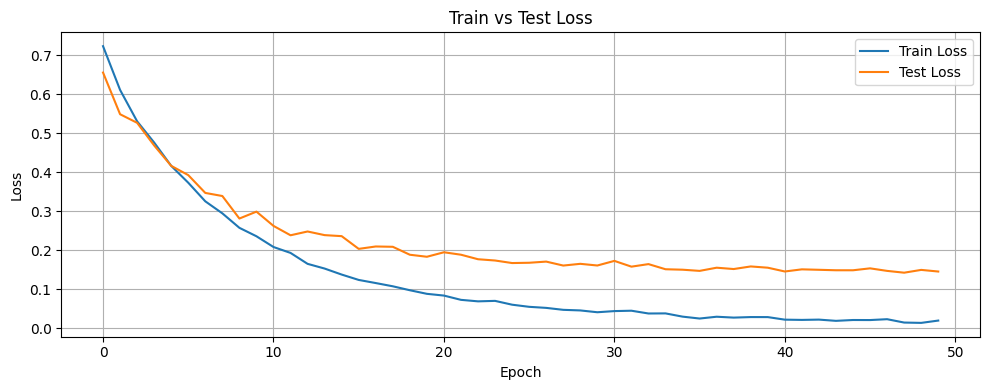

In [ ]:
# @title Result {"vertical-output":true,"display-mode":"form"}
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Train vs Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### **2.5 Plotting results**



#### **2.5.1 Visualizing predictions for some counties**

This section provides a visual comparison between the predicted and actual ARI visit counts for ten randomly selected counties.

- For each county, the model’s predictions are plotted against the true values over time
- These plots allow for a qualitative evaluation of the model’s ability to follow the temporal trends in different county-level contexts
- Discrepancies in prediction accuracy can highlight counties where the model struggles due to volatility, scale differences, or local irregularities

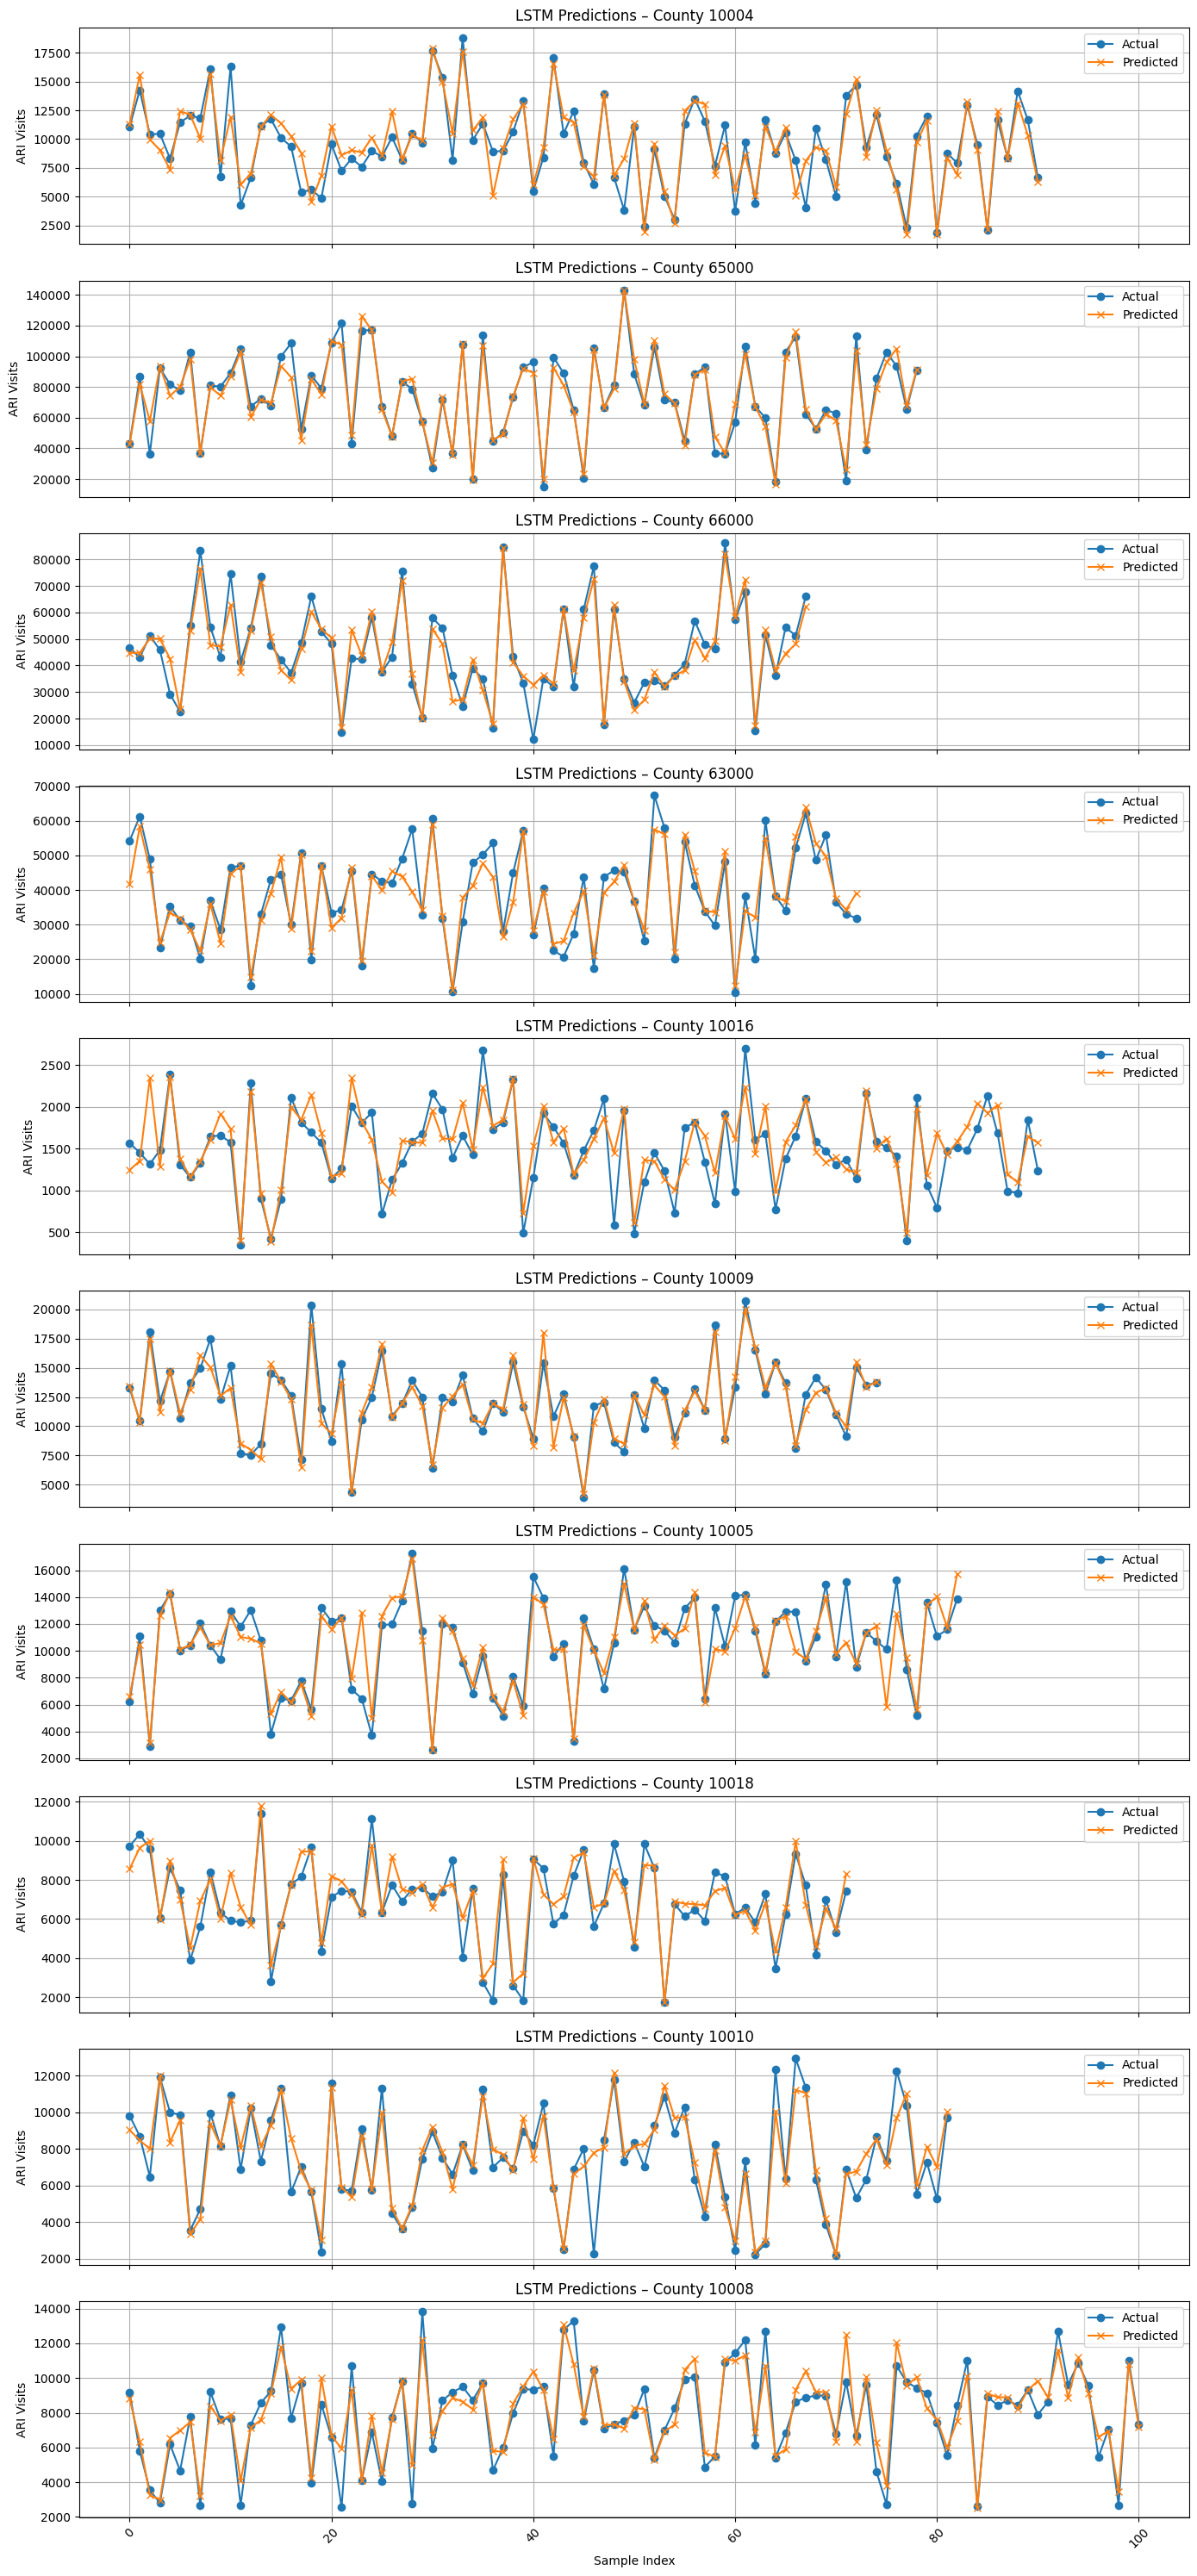

In [ ]:
# @title Result {"vertical-output":true}
import random

# Select 10 random counties from the results
random_counties = random.sample(list(results_by_county.keys()), 10)

fig, axs = plt.subplots(len(random_counties), 1, figsize=(14, 3 * len(random_counties)), sharex=True)

for i, county in enumerate(random_counties):
    y_true = results_by_county[county]['y_true']
    y_pred = results_by_county[county]['y_pred']
    x = list(range(len(y_true)))  # sample index as x-axis

    axs[i].plot(x, y_true, label='Actual', marker='o')
    axs[i].plot(x, y_pred, label='Predicted', marker='x')
    axs[i].set_title(f'LSTM Predictions – County {county}')
    axs[i].set_ylabel('ARI Visits')
    axs[i].grid(True)
    axs[i].legend()

axs[-1].set_xlabel('Sample Index')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### **2.5.2 Prediction Accuracy Within Relative Thresholds**

This section evaluates the model’s prediction accuracy for each county based on relative error margins and investigates how performance varies with the average volume of ARI visits.

- Defines percentage-based thresholds (±2%, ±5%, ±10%, ±20%) to assess the precision of predictions relative to true values.
- Calculates, for each county, the percentage of predictions falling within these relative margins.
- Computes per-county statistics: mean, standard deviation, and coefficient of variation (CV) for ARI visits.
- Sorts counties by their average ARI volume and visualizes their prediction accuracy with grouped bar plots.
- Helps identify which counties the model performs best or worst on, and whether performance correlates with scale or volatility.

In [ ]:
# Define % thresholds relative to the true value
relative_thresholds = [0.02, 0.05, 0.10, 0.20]  # 2%, 5%, 10%, 20%
county_relative_stats = {pct: [] for pct in relative_thresholds}
county_labels = []

# Loop through counties and compute relative accuracy
for county, data in results_by_county.items():
    y_true = np.array(data['y_true'])
    y_pred = np.array(data['y_pred'])

    if len(y_true) == 0:
        continue

    county_labels.append(str(county))

    for pct in relative_thresholds:
        # Compute allowed margin = pct * true value
        margins = pct * np.abs(y_true)
        within_margin = np.abs(y_true - y_pred) <= margins
        accuracy_pct = np.mean(within_margin) * 100
        county_relative_stats[pct].append(accuracy_pct)


ARI Statistics per County (sorted by average):
- County 65000: Mean = 73054, Std = 25919, CV = 0.35
- County 66000: Mean = 47355, Std = 15490, CV = 0.33
- County 64000: Mean = 45781, Std = 16617, CV = 0.36
- County 63000: Mean = 39252, Std = 14310, CV = 0.36
- County 68000: Mean = 31607, Std = 11833, CV = 0.37
- County 67000: Mean = 25881, Std = 8763, CV = 0.34
- County 10007: Mean = 20427, Std = 6592, CV = 0.32
- County 10013: Mean = 13659, Std = 4356, CV = 0.32
- County 10009: Mean = 12394, Std = 4054, CV = 0.33
- County 10005: Mean = 10494, Std = 3460, CV = 0.33
- County 10004: Mean = 9370, Std = 3592, CV = 0.38
- County 10008: Mean = 8304, Std = 2499, CV = 0.30
- County 10002: Mean = 8295, Std = 2828, CV = 0.34
- County 10010: Mean = 7779, Std = 2555, CV = 0.33
- County 10018: Mean = 6730, Std = 2139, CV = 0.32
- County 10017: Mean = 5527, Std = 1857, CV = 0.34
- County 10020: Mean = 5433, Std = 1973, CV = 0.36
- County 10015: Mean = 4705, Std = 1598, CV = 0.34
- County 10014: Mean

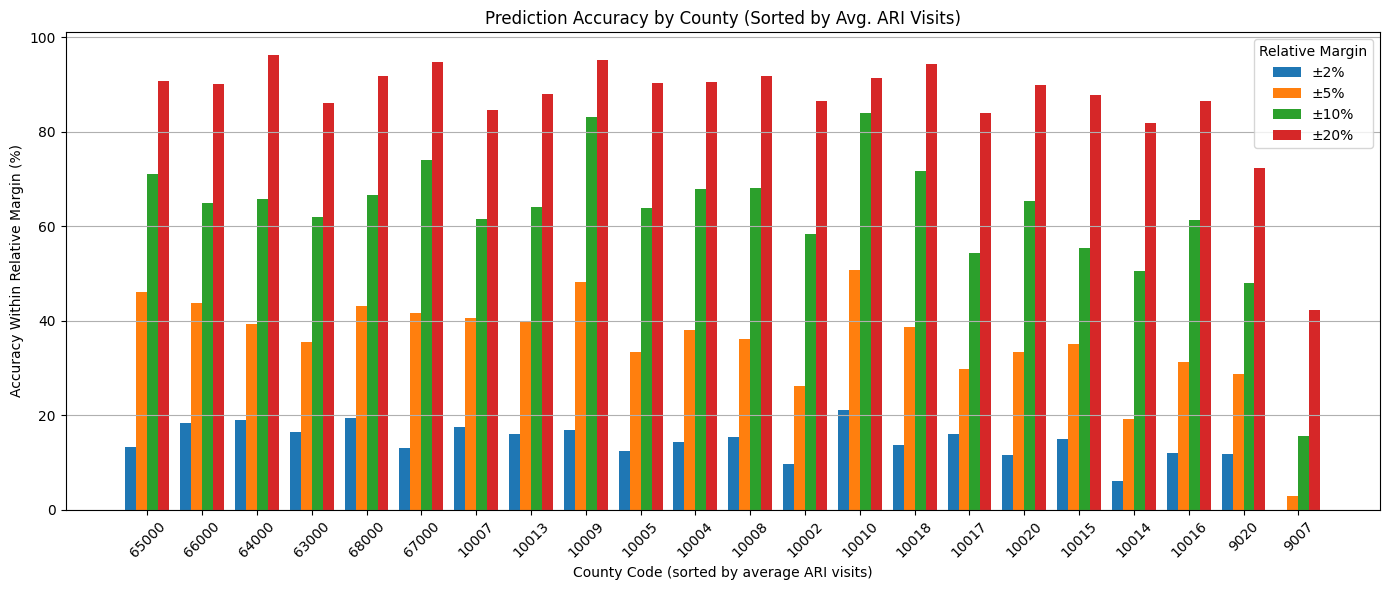

In [ ]:
# @title Mean s.t.d. per county {"vertical-output":true}
# Extract precomputed means and standard deviations per county
mean_by_county = df_county.groupby('county_code')['target_county_mean'].first()
std_by_county = df_county.groupby('county_code')['target_county_std'].first()
cv_by_county = std_by_county / mean_by_county  # Coefficient of Variation (CV)

# Sort counties by decreasing average ARI visits
sorted_counties = mean_by_county.sort_values(ascending=False).index.tolist()
county_labels = [str(c) for c in sorted_counties]

# Reorder accuracy stats based on sorted county order
sorted_stats = {
    pct: [county_relative_stats[pct][list(results_by_county.keys()).index(c)] for c in sorted_counties]
    for pct in relative_thresholds
}

# Print ARI statistics per county
print("ARI Statistics per County (sorted by average):")
for c in sorted_counties:
    mean_val = mean_by_county[c]
    std_val = std_by_county[c]
    cv_val = cv_by_county[c]
    print(f"- County {c}: Mean = {mean_val:.0f}, Std = {std_val:.0f}, CV = {cv_val:.2f}")

# Plot prediction accuracy by county
x = np.arange(len(sorted_counties))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

for i, pct in enumerate(relative_thresholds):
    offset = (i - len(relative_thresholds) / 2) * width + width / 2
    label = f'±{int(pct*100)}%'
    ax.bar(x + offset, sorted_stats[pct], width, label=label)

ax.set_xlabel('County Code (sorted by average ARI visits)')
ax.set_ylabel('Accuracy Within Relative Margin (%)')
ax.set_title('Prediction Accuracy by County (Sorted by Avg. ARI Visits)')
ax.set_xticks(x)
ax.set_xticklabels(county_labels, rotation=45)
ax.legend(title='Relative Margin')
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

### **2.6 Result analysis**

The county-aware LSTM model, enhanced with proper normalization and county embeddings, significantly improved prediction accuracy across most counties. The relative margin analysis shows:

- High accuracy within ±20% for the vast majority of counties, even for those with lower average ARI visits.
- Smaller counties (like 9007) remain harder to predict precisely, due to their low volume and high coefficient of variation (CV = 0.54).
- The model generalizes well, especially for counties with stable and high-volume ARI trends.
- Increasing model complexity (hidden_size = 128) helped reduce underfitting and better captured local dynamics.

While some counties still show room for improvement, these results validate the effectiveness of a unified, county-aware model in capturing localized health visit trends.


### **2.7 Limitations and improvements of the county-aware LSTM approach**

As a **next step**, it could be interesting to compare this unified model with alternative strategies, such as:

- Training a separate LSTM for each county
- Grouping counties by size or volume (small, medium, large) and training one LSTM per group.

This would help assess whether a more specialized or segmented modeling approach could further enhance prediction accuracy for counties with extreme characteristics.